____
# COMPUTE GRADIENT, INTERPOLATE AND ROTATE SWOT DATA ON COLOC POINTS

In [23]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir_2km, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_2km, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

_______
# Data

In [24]:
dfs = browse_swot_2km().reset_index()
#drifters_sources = 'all_med_variational_10min_v0.nc'
drifters_sources = 'all_med_lowess_10min_v0.nc'
df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))#.drop(columns='Unnamed: 0')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_12338/1780576625.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))#.drop(columns='Unnamed: 0')


__________
# SWOT

In [25]:
# get grid orientation and metrics
def add_grid_metrics(ds):
    """ add grid spatial metrics """

    geod = Geod(ellps="WGS84")

    lon, lat = ds.longitude, ds.latitude
    dims = lon.dims
    
    # d/dx where x is cross-track
    az12, az21, dx = geod.inv(
        lon, lat, lon.shift(num_pixels=-1), lat.shift(num_pixels=-1),
    )
    
    ds = ds.assign_coords(dx=(dims, dx), phi=(dims, az12*np.pi/180))
    
    ds["dx"] = (
        ds["dx"]
        .ffill("num_pixels")
        .where(ds["duacs_editing_flag"]<5)
    )

    # phi_lon is cross-track direction from north
    ds["phix"] = (
        ds["phi"]
        .ffill("num_pixels")
        .where(ds["duacs_editing_flag"]<5)
    )

    # d/dy where y is along-track
    az12, az21, dy = geod.inv(
        lon, lat, lon.shift(num_lines=-1), lat.shift(num_lines=-1),
    )
    
    # phiy is along-track direction from north
    ds = ds.assign_coords(phi=(dims, az12*np.pi/180))
    ds["phiy"] = (
        ds["phi"]
        .ffill("num_pixels")
        .where(ds["duacs_editing_flag"]<5)
    )
    
    ds = ds.assign_coords(dy=(dims, dy))
    
    ds["dy"] = (
        ds["dy"]
        .ffill("num_lines")
        .where(ds["duacs_editing_flag"]<5)
    )
    ds['phi']=ds['phix']
    return ds

In [26]:
cycle = 500
swath = 3

dss = xr.open_dataset(dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna().file.values[0])
dss= add_grid_metrics(dss)
list(dss.keys())

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


['ancillary_surface_classification_flag',
 'cross_track_distance',
 'cvl_beta_angle',
 'cvl_flag_val',
 'cvl_flag_val_outliers',
 'cvl_mean_dynamic_topography_cnes_cls_22',
 'cvl_mean_sea_surface_cnes_22_hybrid',
 'cvl_nadir_flag_val_mle4_1hz',
 'cvl_nadir_ssha_mle4_1hz',
 'cvl_ocean_tide_fes_2022',
 'cvl_sea_state_bias_cor_model',
 'cvl_ssha_reference',
 'cycle_number',
 'dac',
 'distance_to_coast',
 'duacs_Barotrop_demo1',
 'duacs_Equatorial_gravity_east_demo1',
 'duacs_Equatorial_gravity_west_demo1',
 'duacs_Equatorial_tiw_demo1',
 'duacs_GeoLongScale_demo1',
 'duacs_GeoSmallScale_demo1',
 'duacs_LongWavelenghtError_swon_demo1',
 'duacs_LongWavelenghtError_swonc_demo1',
 'duacs_bias_karin_nadir',
 'duacs_distance_to_coast',
 'duacs_editing_flag',
 'duacs_land_sea_mask',
 'duacs_nadir_orbit_error',
 'duacs_phase_screen',
 'duacs_phase_screen_orbit',
 'duacs_phase_screen_static',
 'duacs_relative_vorticity',
 'duacs_speed_meridional',
 'duacs_speed_meridional_abs',
 'duacs_speed_zonal

In [27]:
ggd_variables = ['cvl_mean_dynamic_topography_cnes_cls_22',
                'distance_to_coast',
                 'cvl_mean_sea_surface_cnes_22_hybrid',
                 'cvl_ocean_tide_fes_2022',
                 'cvl_ssha_reference',
                 'duacs_ssha_karin_2_calibrated',
                 'duacs_ssha_karin_2_filtered',
                'duacs_ssha_karin_2_oi',
                 'internal_tide_hret',
                 'mean_sea_surface_cnescls',
                 'ocean_tide_fes',
                 'ssh_karin_uncert',
                  ]

variables = ['ancillary_surface_classification_flag',
             'cross_track_distance',
             'duacs_editing_flag',
             'duacs_phase_screen',
             'duacs_phase_screen_orbit',
             'duacs_phase_screen_static',
             'duacs_relative_vorticity',
             'duacs_speed_meridional',
             'duacs_speed_meridional_abs',
             'duacs_speed_zonal',
             'duacs_speed_zonal_abs',
             'duacs_strain',
             'duacs_xcal',
             'sig0_karin_2',
             'phi',]

In [28]:
[v for v in ggd_variables if v not in dss]

[]

# Compute gradient

## Naive way

In [42]:
# Compute ggd with "naive" approach, noise will have an impact
g = 9.80665

def gradient_naive(dss, ggd_variables=None):
    if ggd_variables : dss_ggd = dss[ggd_variables]
    dx = dss_ggd.dx.mean() # meters
    dy = dss_ggd.dy.mean()
    
    dss_ggdx = (g*dss_ggd.differentiate("num_pixels")/dx).rename({v:'ggdx_'+v for v in dss_ggd}).where(~dss['duacs_ssha_karin_2_filtered'].isnull())
    dss_ggdy = (g*dss_ggd.differentiate("num_lines")/dy).rename({v:'ggdy_'+v for v in dss_ggd}).where(~dss['duacs_ssha_karin_2_filtered'].isnull())
    return xr.merge([dss_ggdx, dss_ggdy])

dss_naive = gradient_naive(dss, ggd_variables).sel(num_lines=slice(90, 480))

In [43]:
dss_naive

<xarray.Dataset> Size: 6MB
Dimensions:                                       (num_lines: 390,
                                                   num_pixels: 69)
Coordinates:
    latitude                                      (num_lines, num_pixels) float64 215kB ...
    latitude_nadir                                (num_lines) float64 3kB 36....
    longitude                                     (num_lines, num_pixels) float64 215kB ...
    longitude_nadir                               (num_lines) float64 3kB 3.4...
    time                                          (num_lines) datetime64[ns] 3kB ...
    dx                                            (num_lines, num_pixels) float64 215kB ...
    phi                                           (num_lines, num_pixels) float64 215kB ...
    dy                                            (num_lines, num_pixels) float64 215kB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/24)
    ggdx_cvl_mean_dynamic_topography_cnes_cls_22  (num_lines, num_pixels) float64 215kB ...
    ggdx_distance_to_coast                        (num_lines, num_pixels) float64 215kB ...
    ggdx_cvl_mean_sea_surface_cnes_22_hybrid      (num_lines, num_pixels) float64 215kB ...
    ggdx_cvl_ocean_tide_fes_2022                  (num_lines, num_pixels) float64 215kB ...
    ggdx_cvl_ssha_reference                       (num_lines, num_pixels) float64 215kB ...
    ggdx_duacs_ssha_karin_2_calibrated            (num_lines, num_pixels) float64 215kB ...
    ...                                            ...
    ggdy_duacs_ssha_karin_2_filtered              (num_lines, num_pixels) float64 215kB ...
    ggdy_duacs_ssha_karin_2_oi                    (num_lines, num_pixels) float64 215kB ...
    ggdy_internal_tide_hret                       (num_lines, num_pixels) float64 215kB ...
    ggdy_mean_sea_surface_cnescls                 (num_lines, num_pixels) float64 215kB ...
    ggdy_ocean_tide_fes                           (num_lines, num_pixels) float64 215kB ...
    ggdy_ssh_karin_uncert                         (num_lines, num_pixels) float64 215kB ...

## Gaussian gradient

In [46]:
# gaussian derivative
from scipy.ndimage import gaussian_filter

def gradient_gauss(dss, cutoff, ggd_variables=None, **kwargs):
    
    if ggd_variables : dss_ggd = dss[ggd_variables]
    
    dx = float(dss_ggd.dx.mean())
    dy = float(dss_ggd.dy.mean())

    dss_ggdx = xr.Dataset()
    dss_ggdy = xr.Dataset()
    
    for v in dss_ggd : 
        da = dss_ggd[v].interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines')# prevent nan to spread
        
        # cross-track
        i = da.get_axis_num("num_pixels")
        order = [0,0]
        order[i] = 1
        dss_ggdx['ggdx_'+v] = g*(xr.DataArray(gaussian_filter(da, sigma=cutoff/dx, order=order, **kwargs), dims=da.dims)/dx).where(~dss['duacs_ssha_karin_2_filtered'].isnull())
        #da_dx = da_dx.where(da)
        
        # along-track
        i = da.get_axis_num("num_lines")
        order = [0,0]
        order[i] = 1
        dss_ggdy['ggdy_'+v] = g*(xr.DataArray(gaussian_filter(da, sigma=cutoff/dy, order=order, **kwargs), dims=da.dims)/dy).where(~dss['duacs_ssha_karin_2_filtered'].isnull())
        
    return xr.merge([dss_ggdx, dss_ggdy])


dss_gauss1e3 = gradient_gauss(dss, 1e3, ggd_variables, mode ='nearest').sel(num_lines=slice(90, 480))
dss_gauss2e3 = gradient_gauss(dss, 2e3, ggd_variables, mode ='nearest').sel(num_lines=slice(90, 480))
dss_gauss3e3 = gradient_gauss(dss, 3e3, ggd_variables, mode ='nearest').sel(num_lines=slice(90, 480))
dss_gauss4e3 = gradient_gauss(dss, 4e3, ggd_variables, mode ='nearest').sel(num_lines=slice(90, 480))
dss_gauss5e3 = gradient_gauss(dss, 5e3, ggd_variables, mode ='nearest').sel(num_lines=slice(90, 480))
dss_gauss1e4 = gradient_gauss(dss, 1e4, ggd_variables, mode ='nearest').sel(num_lines=slice(90, 480))

Text(0.5, 1.0, 'Gaussian 5e3')

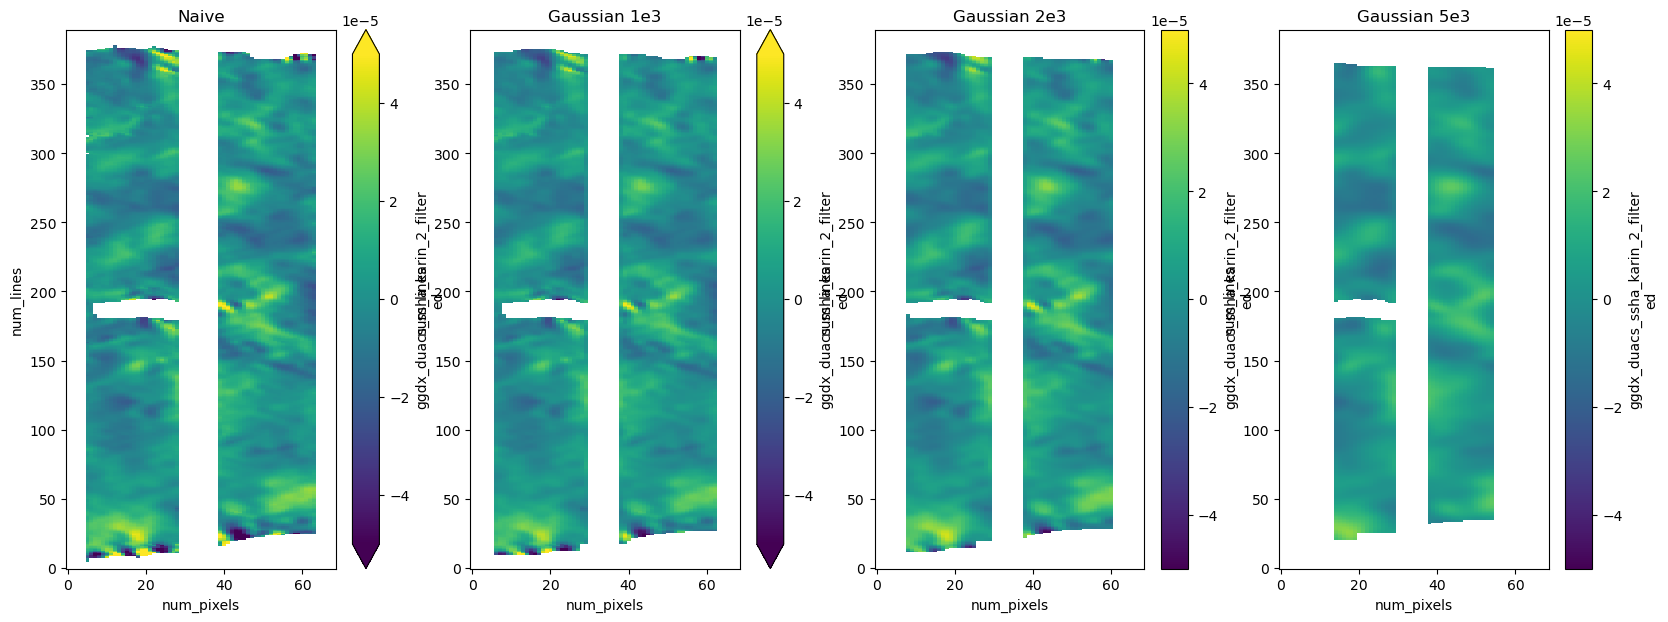

In [47]:
fig, axes = plt.subplots(1,4, figsize=(20,7))
dss_naive.ggdx_duacs_ssha_karin_2_filtered.plot(ax=axes[0], vmin = -5e-5, vmax = 5e-5)
axes[0].set_title('Naive')
dss_gauss1e3.ggdx_duacs_ssha_karin_2_filtered.plot(ax=axes[1], vmin = -5e-5, vmax = 5e-5)
axes[1].set_title('Gaussian 1e3')
dss_gauss2e3.ggdx_duacs_ssha_karin_2_filtered.plot(ax=axes[2], vmin = -5e-5, vmax = 5e-5)
axes[2].set_title('Gaussian 2e3')
dss_gauss5e3.ggdx_duacs_ssha_karin_2_filtered.plot(ax=axes[3], vmin = -5e-5, vmax = 5e-5)
axes[3].set_title('Gaussian 5e3')
#(dss_gauss.ggdx_duacs_ssha_karin_2_filtered-dss_naive.ggdx_duacs_ssha_karin_2_filtered).plot(ax=axes[2], vmin = -5e-6, vmax = 5e-6)
#axes[2].set_title('Gaussian-Naive')

Text(0.5, 1.0, 'Gaussian 5e3')

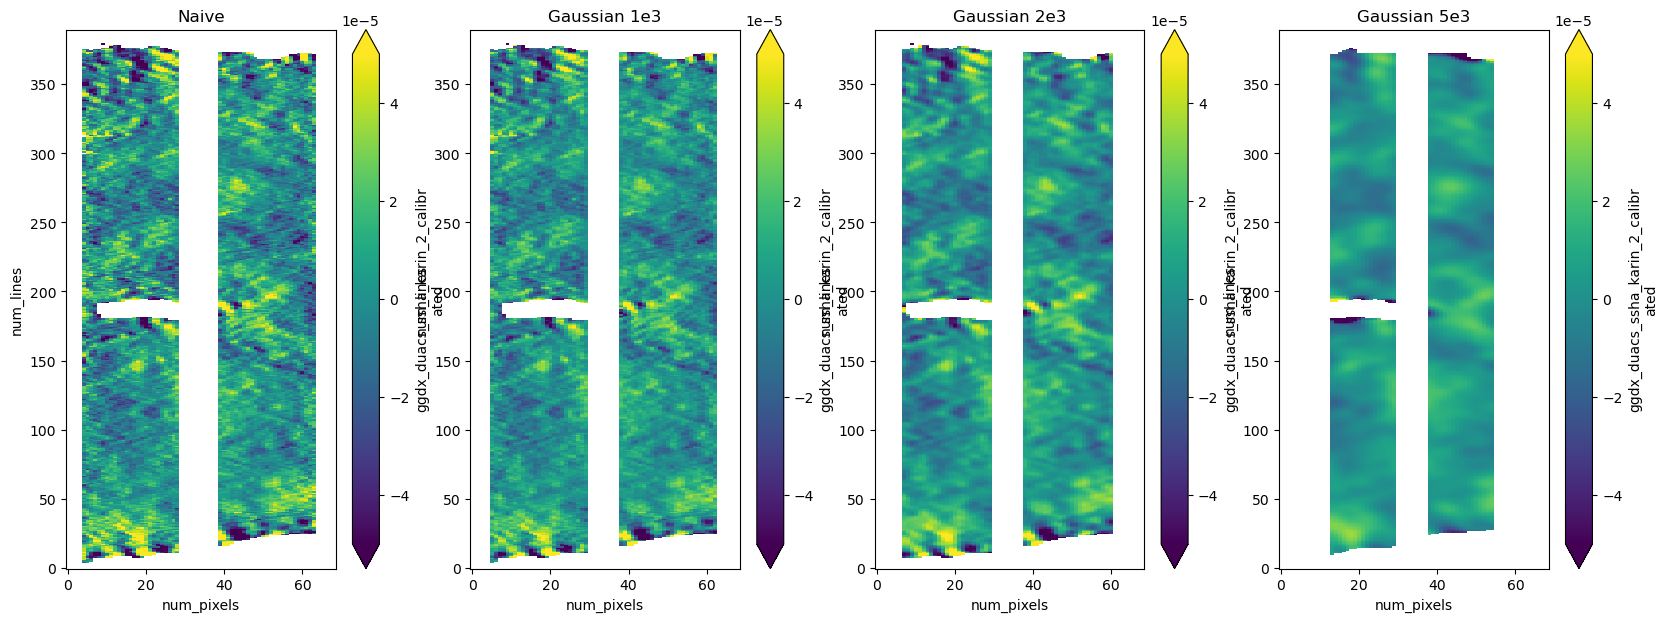

In [48]:
fig, axes = plt.subplots(1,4, figsize=(20,7))
dss_naive.ggdx_duacs_ssha_karin_2_calibrated.plot(ax=axes[0], vmin = -5e-5, vmax = 5e-5)
axes[0].set_title('Naive')
dss_gauss1e3.ggdx_duacs_ssha_karin_2_calibrated.plot(ax=axes[1], vmin = -5e-5, vmax = 5e-5)
axes[1].set_title('Gaussian 1e3')
dss_gauss2e3.ggdx_duacs_ssha_karin_2_calibrated.plot(ax=axes[2], vmin = -5e-5, vmax = 5e-5)
axes[2].set_title('Gaussian 2e3')
dss_gauss5e3.ggdx_duacs_ssha_karin_2_calibrated.plot(ax=axes[3], vmin = -5e-5, vmax = 5e-5)
axes[3].set_title('Gaussian 5e3')
#(dss_gauss.ggdx_duacs_ssha_karin_2_filtered-dss_naive.ggdx_duacs_ssha_karin_2_filtered).plot(ax=axes[2], vmin = -5e-6, vmax = 5e-6)
#axes[2].set_title('Gaussian-Naive')

Text(0.5, 1.0, 'Gaussian 1e4')

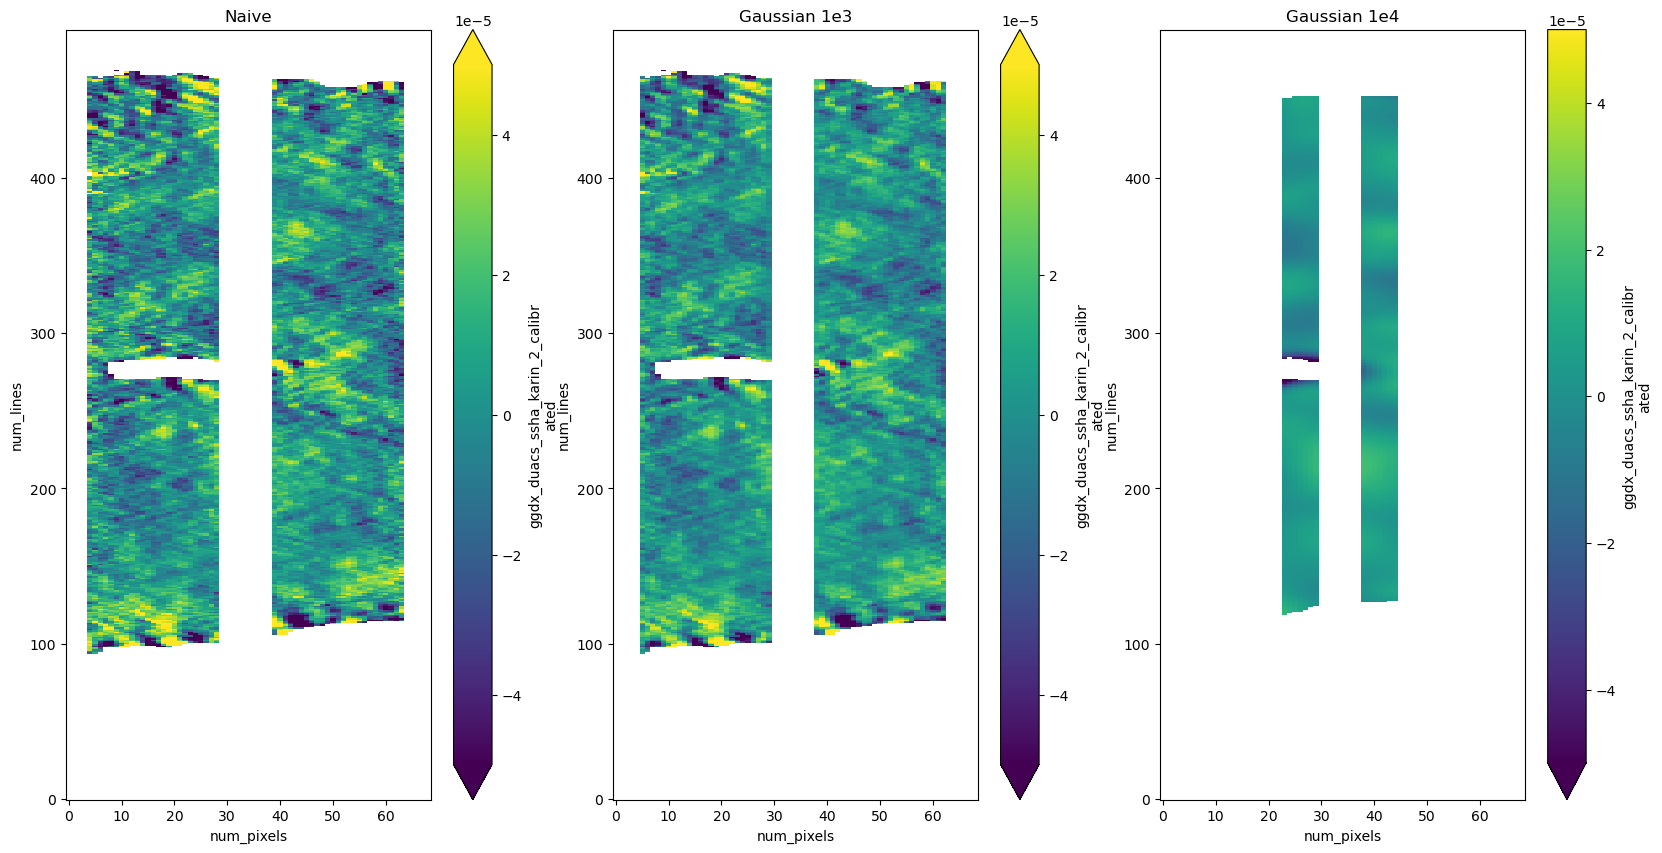

In [13]:
fig, axes = plt.subplots(1,3, figsize=(20,10))
dss_naive.ggdx_duacs_ssha_karin_2_calibrated.plot(ax=axes[0], vmin = -5e-5, vmax = 5e-5)
axes[0].set_title('Naive')
dss_gauss1e3.ggdx_duacs_ssha_karin_2_calibrated.plot(ax=axes[1], vmin = -5e-5, vmax = 5e-5)
axes[1].set_title('Gaussian 1e3')
dss_gauss1e4.ggdx_duacs_ssha_karin_2_calibrated.plot(ax=axes[2], vmin = -5e-5, vmax = 5e-5)
axes[2].set_title('Gaussian 1e4')
#(dss_gauss.ggdx_duacs_ssha_karin_2_filtered-dss_naive.ggdx_duacs_ssha_karin_2_filtered).plot(ax=axes[2], vmin = -5e-6, vmax = 5e-6)
#axes[2].set_title('Gaussian-Naive')

# Interpolate 

In [14]:
dfr = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))#.drop(columns = 'Unnamed: 0').set_index('row_number')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_12338/2787850939.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfr = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))#.drop(columns = 'Unnamed: 0').set_index('row_number')


In [15]:
dfr_ = dfr.where((dfr.pass_number==swath)&(dfr.cycle_number==cycle)).dropna()

In [16]:
import pyinterp
mesh = pyinterp.RTree()

def interp_one_dataarray(da, new_lon, new_lat):
    lons = da.longitude.compute().data.flatten()
    lats = da.latitude.compute().data.flatten()
    data = da.compute().data.flatten()

    mesh.packing(np.vstack((lons, lats)).T, data)
    mx = new_lon
    my = new_lat

    idw, neighbors = mesh.inverse_distance_weighting(
        np.vstack((mx.ravel(), my.ravel())).T,
        within=False,  # Extrapolation is forbidden
        k=5,  # We are looking for at most 11 neighbors
        num_threads=0,
    )
    idw = idw.reshape(mx.shape)
    return idw

def interp_dss(dss, new_lon, new_lat):
    df_interp = pd.DataFrame()
    df_interp['longitude'] = new_lon
    df_interp['latitude'] = new_lat
    for v in dss : 
        da = dss[v]
        df_interp[v]=interp_one_dataarray(da, new_lon, new_lat)
    return df_interp
        
        

____________
# Compute and interp at once

In [17]:
def coloc_swot_cycle_swath(dfr, dfs, cycle, swath, cutoff, method_gradient='gauss'):
    # select drifter point
    dfr_ = dfr.where((dfr.pass_number==swath)&(dfr.cycle_number==cycle)).dropna()
    dss = xr.open_dataset(dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna().file.values[0])
    dss = add_grid_metrics(dss).reset_coords(['phi'])
    if method_gradient =='naive' :
        dss_ggd= gradient_naive(dss, ggd_variables=ggd_variables)
    if method_gradient == 'gauss' :
        dss_ggd = gradient_gauss(dss, cutoff, ggd_variables)
    dss = xr.merge([dss[variables], dss_ggd])
    df_interp = interp_dss(dss, dfr_.longitude.values, dfr_.latitude.values)
    df_out = pd.concat([dfr_.reset_index()[['row_number', 'longitude']].set_index('longitude'), df_interp.set_index('longitude')], axis=1).reset_index().set_index('row_number')
    rotate_ggd(df_out)
    return df_out

def coloc_swot(dfr, dfs, cutoff, method_gradient='gauss'):
    DF = []
    for swath in dfr.pass_number.unique() : 
        for cycle in dfr.where(dfr.pass_number==swath).dropna().cycle_number.unique():
            DF.append(coloc_swot_cycle_swath(dfr, dfs, cycle,  swath, cutoff, method_gradient))
    return pd.concat(DF)

# Rotate

In [18]:
def rotate(x, y, phi):
    return np.sin(phi)*x - np.cos(phi)*y, np.cos(phi)*x + np.sin(phi)*y
def rotate_ggd(df):
    for v in ggd_variables : 
        df['ggde_'+v], df['ggdn_'+v] = rotate(df['ggdx_'+v], df['ggdy_'+v], df['phi'])

__________
________
# GENERATE


In [19]:
dfr_ = dfr.iloc[0:100]

In [19]:
drifters_sources

'all_med_lowess_10min_v0.nc'

In [20]:
method, cutoff = 'naive', ''
dfsg = coloc_swot(dfr, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg)
dfsg.to_csv(os.path.join(zarr_dir, 'swot_2km_'+drifters_sources.replace('.nc', '')+f'_{method}{cutoff}.csv'))


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

In [21]:
method, cutoff = 'gauss', 1e3
dfsg = coloc_swot(dfr, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg)
dfsg.to_csv(os.path.join(zarr_dir, 'swot_2km_'+drifters_sources.replace('.nc', '')+f'_{method}{cutoff}.csv'))


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

KeyboardInterrupt: 

In [ ]:
method, cutoff = 'gauss', 5e3
dfsg = coloc_swot(dfr, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg)
dfsg.to_csv(os.path.join(zarr_dir, 'swot_2km_'+drifters_sources.replace('.nc', '')+f'_{method}{cutoff}.csv'))


In [22]:
method, cutoff = 'gauss', 2e3
dfsg = coloc_swot(dfr, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg)
dfsg.to_csv(os.path.join(zarr_dir, 'swot_2km_'+drifters_sources.replace('.nc', '')+f'_{method}{cutoff}.csv'))


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

In [20]:
method, cutoff = 'gauss', 3e3
dfsg = coloc_swot(dfr, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg)
dfsg.to_csv(os.path.join(zarr_dir, 'swot_2km_'+drifters_sources.replace('.nc', '')+f'_{method}{cutoff}.csv'))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

In [21]:
method, cutoff = 'gauss', 4e3
dfsg = coloc_swot(dfr, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg)
dfsg.to_csv(os.path.join(zarr_dir, 'swot_2km_'+drifters_sources.replace('.nc', '')+f'_{method}{cutoff}.csv'))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

In [36]:
method, cutoff = 'gauss', 4e3
dfsg = coloc_swot(dfr, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg)
dfsg.to_csv(os.path.join(zarr_dir, 'swot_2km_'+drifters_sources.replace('.nc', '')+f'_{method}{cutoff}.csv'))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh